# Roll组件使用指南：基于 market_data 的实战示例

这份 notebook 的目标是帮助你快速熟悉 `cta_lab/strategies/components/roll/` 目前已经实现的能力。

当前重点覆盖：
- 如何把 `market_data` 中的国内期货日线数据整理成 roll 组件可消费的输入
- 如何构建一个单资产 `SingleAssetRollStrategy`
- 如何查看 `contract_plan / roll_schedule / value_series / lookthrough_book`
- 如何把多个单资产 roll result 组合成一个静态 `bundle roll asset`

当前边界也请先记住：
- 本 notebook 只使用 **generic contract** 数据
- 不处理 `CU.SHF`、`CU00.SHF`、`CU01.SHF` 这类连续链 / alias contract
- bundle 当前先演示 `static` 权重，不进入 `BLACK` 动态权重逻辑

In [1]:
%matplotlib inline

from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('/home/ubuntu/dengl/my_projects/cta_lab')
MARKET_DATA = ROOT.parent / 'market_data'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# 开发期如果你刚改过 roll 组件代码，这里会自动 reload，通常不需要 restart kernel。
import strategies.components.roll as roll_pkg
import strategies.components.roll.bundle as roll_bundle_mod
import strategies.components.roll.profile as roll_profile_mod

importlib.reload(roll_bundle_mod)
importlib.reload(roll_profile_mod)
importlib.reload(roll_pkg)

from strategies.components.roll import (
    BundleRollStrategy,
    BundleRule,
    ExecutionRuleConfig,
    GMAT3SingleAssetRollStrategy,
    LifecycleRuleConfig,
    MarketStateRuleConfig,
    RollComponentProfile,
    RollStrategyProfile,
    SelectorRuleConfig,
    build_gmat3_black_bundle_market_data,
    build_gmat3_black_bundle_profile,
    build_single_asset_strategy_from_profile,
    run_gmat3_black_bundle,
)
from strategies.implementations.gmat3 import GMAT3DataAccess

plt.rcParams['figure.dpi'] = 120
ROOT, MARKET_DATA


(PosixPath('/home/ubuntu/dengl/my_projects/cta_lab'),
 PosixPath('/home/ubuntu/dengl/my_projects/market_data'))

## 1. 准备一个把 market_data 转成 roll layer 输入的 helper

`SingleAssetRollStrategy` 当前期望的输入是一个 `market_data` dict，至少包含：
- `contracts`：合约生命周期表
- `prices`：`trade_date x contract_id` 的宽表
- `open_interest`：`trade_date x contract_id` 的宽表

下面这个 helper 直接从 `market_data/contracts/china/contract_info.parquet` 和 `market_data/kline/china_daily_full/{symbol}.parquet` 读取真实数据，并规范化成 roll 组件能直接消费的格式。

In [13]:
def load_china_generic_contract_market_data(symbol: str, start=None, end=None, root: Path = MARKET_DATA) -> dict:
    contract_path = root / 'contracts' / 'china' / 'contract_info.parquet'
    kline_path = root / 'kline' / 'china_daily_full' / f'{symbol}.parquet'

    contracts_raw = pd.read_parquet(contract_path)
    contracts_raw = contracts_raw.loc[contracts_raw['fut_code'] == symbol].copy()
    if contracts_raw.empty:
        raise ValueError(f'No contract info found for {symbol}')

    contracts = contracts_raw.rename(
        columns={
            'ts_code': 'contract_id',
            'delist_date': 'last_trade_date',
            'last_ddate': 'last_holding_date',
        }
    )
    contracts['last_trade_date'] = pd.to_datetime(contracts['last_trade_date'].astype(str), format='%Y%m%d')
    contracts['last_holding_date'] = pd.to_datetime(contracts['last_holding_date'].astype(str), format='%Y%m%d', errors='coerce')
    contracts = contracts[['contract_id', 'symbol', 'exchange', 'last_trade_date', 'last_holding_date']].copy()
    contracts = contracts.sort_values('last_trade_date').reset_index(drop=True)

    daily = pd.read_parquet(kline_path).copy()
    daily['trade_date'] = pd.to_datetime(daily['trade_date'])
    if start is not None:
        daily = daily.loc[daily['trade_date'] >= pd.Timestamp(start)].copy()
    if end is not None:
        daily = daily.loc[daily['trade_date'] <= pd.Timestamp(end)].copy()

    allowed_contracts = contracts['contract_id'].astype(str).tolist()
    daily = daily.loc[daily['contract_code'].isin(allowed_contracts)].copy()

    prices = (
        daily.pivot_table(index='trade_date', columns='contract_code', values='settle_price', aggfunc='last')
        .sort_index()
        .reindex(columns=allowed_contracts)
    )
    open_interest = (
        daily.pivot_table(index='trade_date', columns='contract_code', values='interest', aggfunc='last')
        .sort_index()
        .reindex(columns=allowed_contracts)
    )

    return {
        'contracts': contracts,
        'prices': prices,
        'open_interest': open_interest,
        'raw_daily': daily,
        'symbol': symbol,
        'uses_generic_contract_only': True,
    }


## 2. 看一个真实单资产输入：`CU`

这里先选 `CU` 演示，因为国内金属合约链比较直观。

In [3]:
cu_market_data = load_china_generic_contract_market_data('CU', start='2005-01-01', end='2025-12-31')

print('contracts:', cu_market_data['contracts'].shape)
print('prices:', cu_market_data['prices'].shape)
print('open_interest:', cu_market_data['open_interest'].shape)

display(cu_market_data['contracts'].head())
display(cu_market_data['prices'].iloc[:5, :5])

contracts: (383, 5)
prices: (5103, 383)
open_interest: (5103, 383)


,contract_id,symbol,exchange,last_trade_date,last_holding_date
0,CU9505.SHF,CU9505,SHFE,1995-05-15,NaT
1,CU9506.SHF,CU9506,SHFE,1995-06-15,NaT
2,CU9507.SHF,CU9507,SHFE,1995-07-14,NaT
3,CU9508.SHF,CU9508,SHFE,1995-08-15,NaT
4,CU9509.SHF,CU9509,SHFE,1995-09-15,NaT


contract_code,CU9505.SHF,CU9506.SHF,CU9507.SHF,CU9508.SHF,CU9509.SHF
trade_date,,,,,
2005-01-04,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN
2005-01-10,NaN,NaN,NaN,NaN,NaN


## 3. 用显式 rule config 构造一个单资产 roll strategy

这是当前最推荐的写法。

四类 config 分别控制：
- `LifecycleRuleConfig`：什么时候必须/可以展期
- `MarketStateRuleConfig`：市场状态变量怎么决定目标合约
- `ExecutionRuleConfig`：old/new 合约如何过渡
- `SelectorRuleConfig`：如何综合 lifecycle 和 market-state 输出

In [4]:
cu_profile = RollStrategyProfile(
    name='cu_demo_roll',
    asset_key='CU',
    asset_mode='single',
    currency='CNY',
    roll_days=3,
    lifecycle_rule_config=LifecycleRuleConfig(
        kind='fixed_days_before_expiry',
        params={'roll_days': 3, 'date_field': 'last_holding_date'},
    ),
    market_state_rule_config=MarketStateRuleConfig(
        kind='field_max',
        params={'field_name': 'open_interest'},
    ),
    execution_rule_config=ExecutionRuleConfig(
        kind='linear',
        params={'roll_days': 3},
    ),
    selector_rule_config=SelectorRuleConfig(
        kind='hybrid',
        params={},
    ),
)

cu_strategy = build_single_asset_strategy_from_profile(cu_profile)
cu_result = cu_strategy.run(market_data=cu_market_data)

type(cu_result).__name__

'RollStrategyResult'

## 4. 看单资产输出对象

这是理解 roll 组件最重要的一步：

- `contract_plan`：目标合约决策
- `roll_schedule`：执行层路径
- `value_series`：上层可消费的资产级价值序列
- `lookthrough_book`：底层持仓穿透

In [30]:
display(cu_result.contract_plan.head(10))
display(cu_result.roll_schedule.head(10))
display(cu_result.lookthrough_view().head(10))
cu_result.value_series.head()

,trade_date,current_contract,target_contract,reason,must_roll
0,2005-01-04,NaN,CU0503.SHF,initialize_from_market_state,True
1,2005-01-05,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
2,2005-01-06,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
3,2005-01-07,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
4,2005-01-10,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
5,2005-01-11,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
6,2005-01-12,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
7,2005-01-13,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
8,2005-01-14,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True
9,2005-01-17,CU0503.SHF,CU0503.SHF,lifecycle_forced_roll,True


,trade_date,contract_id,weight,leg
0,2005-01-04,CU0503.SHF,1.0,active
1,2005-01-05,CU0503.SHF,1.0,active
2,2005-01-06,CU0503.SHF,1.0,active
3,2005-01-07,CU0503.SHF,1.0,active
4,2005-01-10,CU0503.SHF,1.0,active
5,2005-01-11,CU0503.SHF,1.0,active
6,2005-01-12,CU0503.SHF,1.0,active
7,2005-01-13,CU0503.SHF,1.0,active
8,2005-01-14,CU0503.SHF,1.0,active
9,2005-01-17,CU0503.SHF,1.0,active


,trade_date,contract_id,exposure_weight,leg
0,2005-01-04,CU0503.SHF,1.0,active
1,2005-01-05,CU0503.SHF,1.0,active
2,2005-01-06,CU0503.SHF,1.0,active
3,2005-01-07,CU0503.SHF,1.0,active
4,2005-01-10,CU0503.SHF,1.0,active
5,2005-01-11,CU0503.SHF,1.0,active
6,2005-01-12,CU0503.SHF,1.0,active
7,2005-01-13,CU0503.SHF,1.0,active
8,2005-01-14,CU0503.SHF,1.0,active
9,2005-01-17,CU0503.SHF,1.0,active


trade_date
2005-01-04    1.000000
2005-01-05    0.969854
2005-01-06    0.983368
2005-01-07    0.984754
2005-01-10    0.979903
dtype: float64

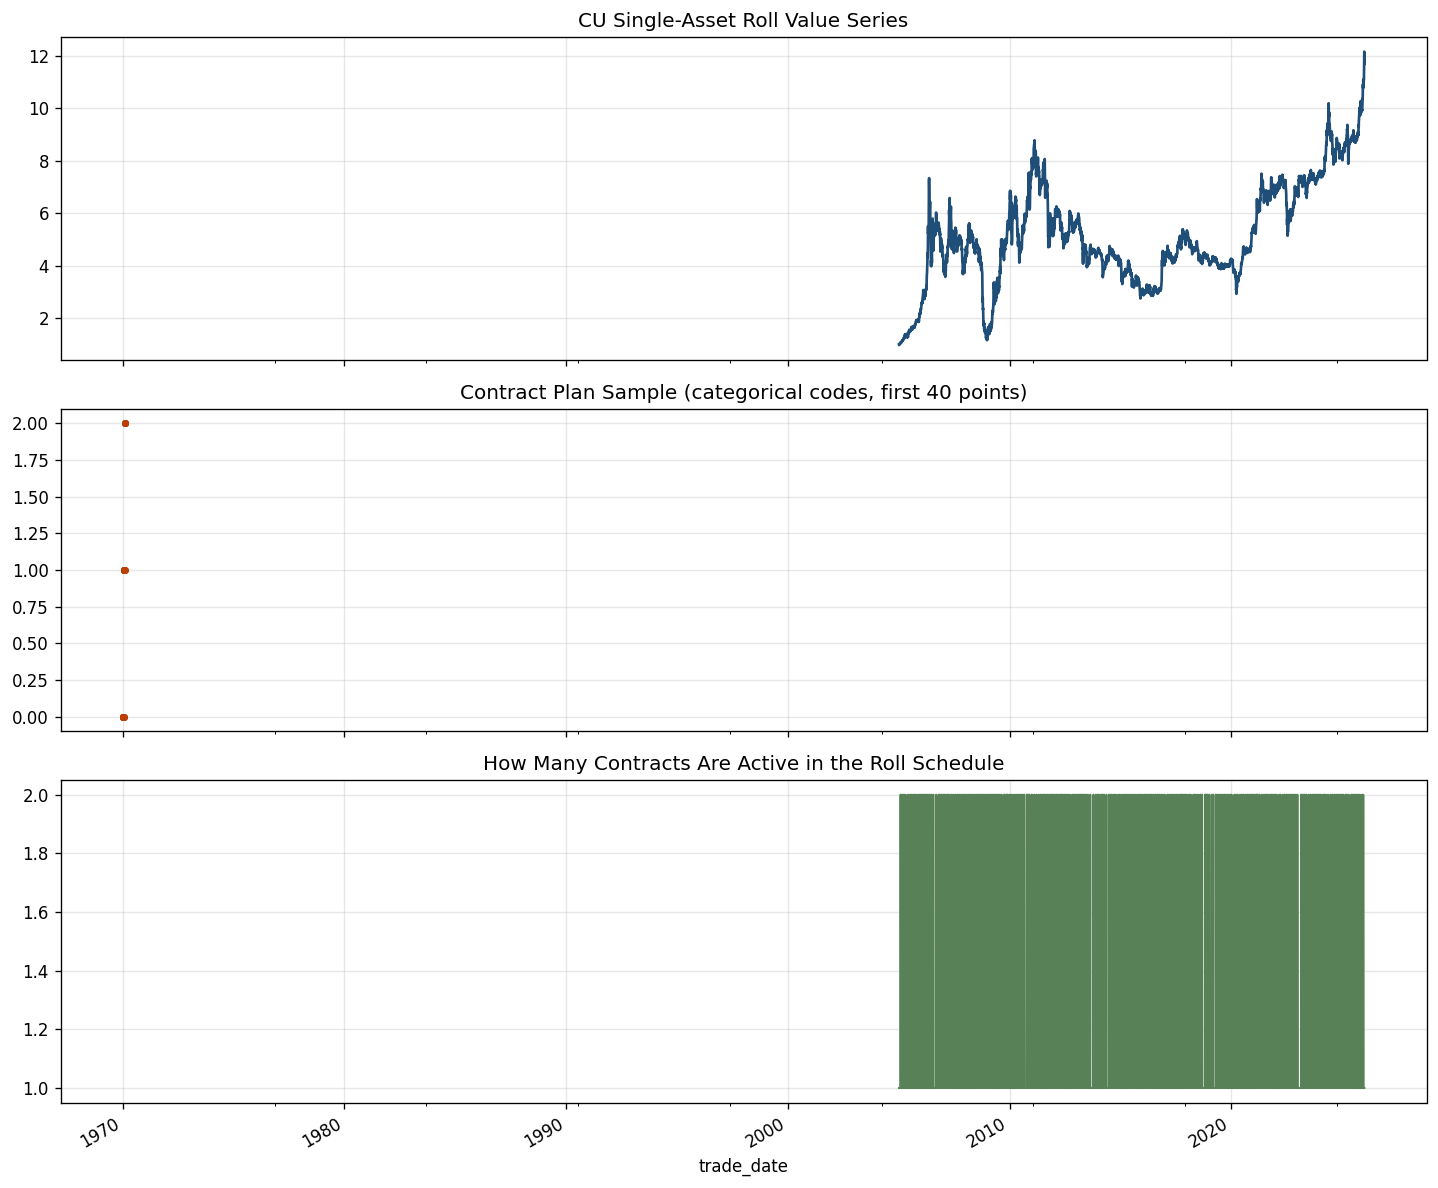

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

cu_result.value_series.plot(ax=axes[0], color='#1f4e79', lw=1.6)
axes[0].set_title('CU Single-Asset Roll Value Series')
axes[0].grid(alpha=0.3)

plan_sample = cu_result.contract_plan[['trade_date', 'target_contract']].dropna().drop_duplicates('trade_date').set_index('trade_date')
plan_codes = pd.Series(pd.factorize(plan_sample['target_contract'].astype(str))[0], index=plan_sample.index)
plan_codes.iloc[:40].reset_index(drop=True).plot(ax=axes[1], style='.', color='#bb3e03')
axes[1].set_title('Contract Plan Sample (categorical codes, first 40 points)')
axes[1].grid(alpha=0.3)

schedule_sample = cu_result.roll_schedule.groupby('trade_date')['contract_id'].nunique()
schedule_sample.plot(ax=axes[2], color='#588157', lw=1.2)
axes[2].set_title('How Many Contracts Are Active in the Roll Schedule')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

上面的第二张图只是帮助你直观看切换节奏，不是很优雅的图形。更实用的调试方式通常是直接筛选某一段换仓窗口。

In [5]:
roll_window = cu_result.roll_schedule.loc[
    (pd.to_datetime(cu_result.roll_schedule['trade_date']) >= pd.Timestamp('2005-01-01'))
    & (pd.to_datetime(cu_result.roll_schedule['trade_date']) <= pd.Timestamp('2025-12-31'))
]
display(roll_window)

,trade_date,contract_id,weight,leg
0,2005-01-04,CU0503.SHF,1.0,active
1,2005-01-05,CU0503.SHF,1.0,active
2,2005-01-06,CU0503.SHF,1.0,active
3,2005-01-07,CU0503.SHF,1.0,active
4,2005-01-10,CU0503.SHF,1.0,active
...,...,...,...,...
5598,2025-12-25,CU2602.SHF,1.0,active
5599,2025-12-26,CU2602.SHF,1.0,active
5600,2025-12-29,CU2602.SHF,1.0,active
5601,2025-12-30,CU2602.SHF,1.0,active


## 5. 再跑一个单资产结果，为 bundle 做准备

这里用 `AL`，这样我们可以演示一个简单的“金属双腿 bundle”。

In [6]:
al_market_data = load_china_generic_contract_market_data('AL', start='2005-01-01', end='2025-12-31')

al_profile = RollStrategyProfile(
    name='al_demo_roll',
    asset_key='AL',
    asset_mode='single',
    currency='CNY',
    roll_days=3,
    lifecycle_rule_config=LifecycleRuleConfig(
        kind='fixed_days_before_expiry',
        params={'roll_days': 3, 'date_field': 'last_holding_date'},
    ),
    market_state_rule_config=MarketStateRuleConfig(
        kind='field_max',
        params={'field_name': 'open_interest'},
    ),
    execution_rule_config=ExecutionRuleConfig(
        kind='linear',
        params={'roll_days': 3},
    ),
    selector_rule_config=SelectorRuleConfig(
        kind='hybrid',
        params={},
    ),
)

al_strategy = build_single_asset_strategy_from_profile(al_profile)
al_result = al_strategy.run(market_data=al_market_data)

print('CU last value:', float(cu_result.value_series.iloc[-1]))
print('AL last value:', float(al_result.value_series.iloc[-1]))

CU last value: 11.871092818468805
AL last value: 0.9999970790680824


## 6. 用两个单资产结果构造一个静态 bundle roll asset

当前 bundle 第一版的思路是：
- 先把底层单资产 roll result 各自跑出来
- 再用 `BundleRollStrategy` 在上层把它们合成一个资产

这非常适合你先做原型验证，例如：
- 近月/次近月双腿
- 金属双腿
- 简化版 BLACK-like bundle

In [7]:
metal_bundle_profile = RollStrategyProfile(
    name='metal_bundle_demo',
    asset_key='CU_AL_BUNDLE',
    asset_mode='bundle',
    currency='CNY',
    components=[
        RollComponentProfile(component_key='cu', symbol='CU'),
        RollComponentProfile(component_key='al', symbol='AL'),
    ],
    bundle_rule=BundleRule(
        weight_mode='static',
        static_weights={'cu': 0.6, 'al': 0.4},
    ),
)

metal_bundle = BundleRollStrategy(metal_bundle_profile)
metal_bundle_result = metal_bundle.run(
    market_data={
        'component_results': {
            'cu': cu_result,
            'al': al_result,
        }
    }
)

display(metal_bundle_result.component_weights.head())
display(metal_bundle_result.lookthrough_view().head(10))
metal_bundle_result.value_series.tail()

,cu,al
trade_date,,
2005-01-04,0.6,0.4
2005-01-05,0.6,0.4
2005-01-06,0.6,0.4
2005-01-07,0.6,0.4
2005-01-10,0.6,0.4


,trade_date,contract_id,exposure_weight,leg,component_key,bundle_weight
0,2005-01-04,CU0503.SHF,1.0,active,cu,0.6
1,2005-01-05,CU0503.SHF,1.0,active,cu,0.6
2,2005-01-06,CU0503.SHF,1.0,active,cu,0.6
3,2005-01-07,CU0503.SHF,1.0,active,cu,0.6
4,2005-01-10,CU0503.SHF,1.0,active,cu,0.6
5,2005-01-11,CU0503.SHF,1.0,active,cu,0.6
6,2005-01-12,CU0503.SHF,1.0,active,cu,0.6
7,2005-01-13,CU0503.SHF,1.0,active,cu,0.6
8,2005-01-14,CU0503.SHF,1.0,active,cu,0.6
9,2005-01-17,CU0503.SHF,1.0,active,cu,0.6


trade_date
2025-12-25    4.950247
2025-12-26    5.093019
2025-12-29    5.208171
2025-12-30    5.069993
2025-12-31    5.161361
Name: CU_AL_BUNDLE, dtype: float64

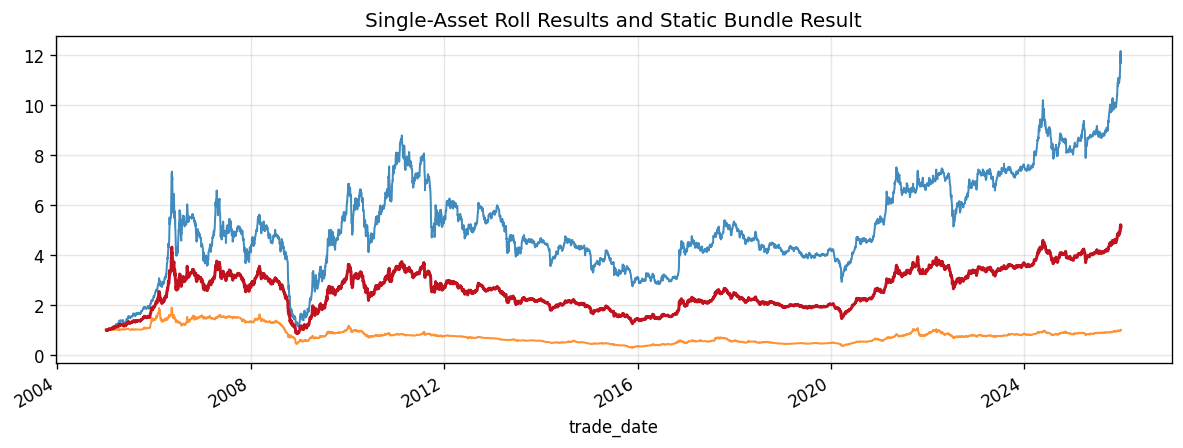

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
cu_result.value_series.rename('CU').plot(ax=ax, lw=1.2, alpha=0.85)
al_result.value_series.rename('AL').plot(ax=ax, lw=1.2, alpha=0.85)
metal_bundle_result.value_series.rename('CU_AL_BUNDLE').plot(ax=ax, lw=1.8, color='#c1121f')
ax.set_title('Single-Asset Roll Results and Static Bundle Result')
ax.grid(alpha=0.3)
plt.show()

## 7. 在 bundle 上使用 external dynamic weights

现在 roll 组件第二阶段已经支持：
- 由外部提供一张时间变化的 `component_target_weights`
- `BundleRollStrategy` 负责消费这张权重表
- 可选 `rebalance_frequency` + `smoothing_window`

这非常适合作为过渡路径：
- bundle 本身先不负责推导复杂动态权重逻辑
- 但已经可以接住外部算好的目标权重
- 特别适合以后对接 `BLACK` 或其他跨资产配置规则


In [9]:
dynamic_target_weights = pd.DataFrame(
    {
        'cu': [0.8, 0.8, 0.8, 0.3, 0.3, 0.3],
        'al': [0.2, 0.2, 0.2, 0.7, 0.7, 0.7],
    },
    index=pd.to_datetime([
        '2005-12-28',
        '2005-12-29',
        '2005-12-30',
        '2006-01-03',
        '2006-01-04',
        '2006-01-05',
    ]),
)

dynamic_bundle_profile = RollStrategyProfile(
    name='metal_dynamic_bundle_demo',
    asset_key='CU_AL_DYNAMIC_BUNDLE',
    asset_mode='bundle',
    currency='CNY',
    components=[
        RollComponentProfile(component_key='cu', symbol='CU'),
        RollComponentProfile(component_key='al', symbol='AL'),
    ],
    bundle_rule=BundleRule(
        weight_mode='external',
        rebalance_frequency='monthly',
        smoothing_window=2,
    ),
)

dynamic_bundle = BundleRollStrategy(dynamic_bundle_profile)
dynamic_bundle_result = dynamic_bundle.run(
    market_data={
        'component_results': {
            'cu': cu_result,
            'al': al_result,
        },
        'component_target_weights': dynamic_target_weights,
    }
)

display(dynamic_target_weights)
display(dynamic_bundle_result.component_weights.loc['2005-12-28':'2006-01-06'])
dynamic_bundle_result.value_series.tail()


,cu,al
2005-12-28,0.8,0.2
2005-12-29,0.8,0.2
2005-12-30,0.8,0.2
2006-01-03,0.3,0.7
2006-01-04,0.3,0.7
2006-01-05,0.3,0.7


,cu,al
2005-12-28,0.0,0.0
2005-12-29,0.0,0.0
2005-12-30,0.0,0.0
2006-01-04,0.3,0.7
2006-01-05,0.3,0.7
2006-01-06,0.3,0.7


trade_date
2025-12-25     1.42385
2025-12-26     1.45338
2025-12-29    1.476254
2025-12-30    1.451808
2025-12-31    1.478932
Name: CU_AL_DYNAMIC_BUNDLE, dtype: object

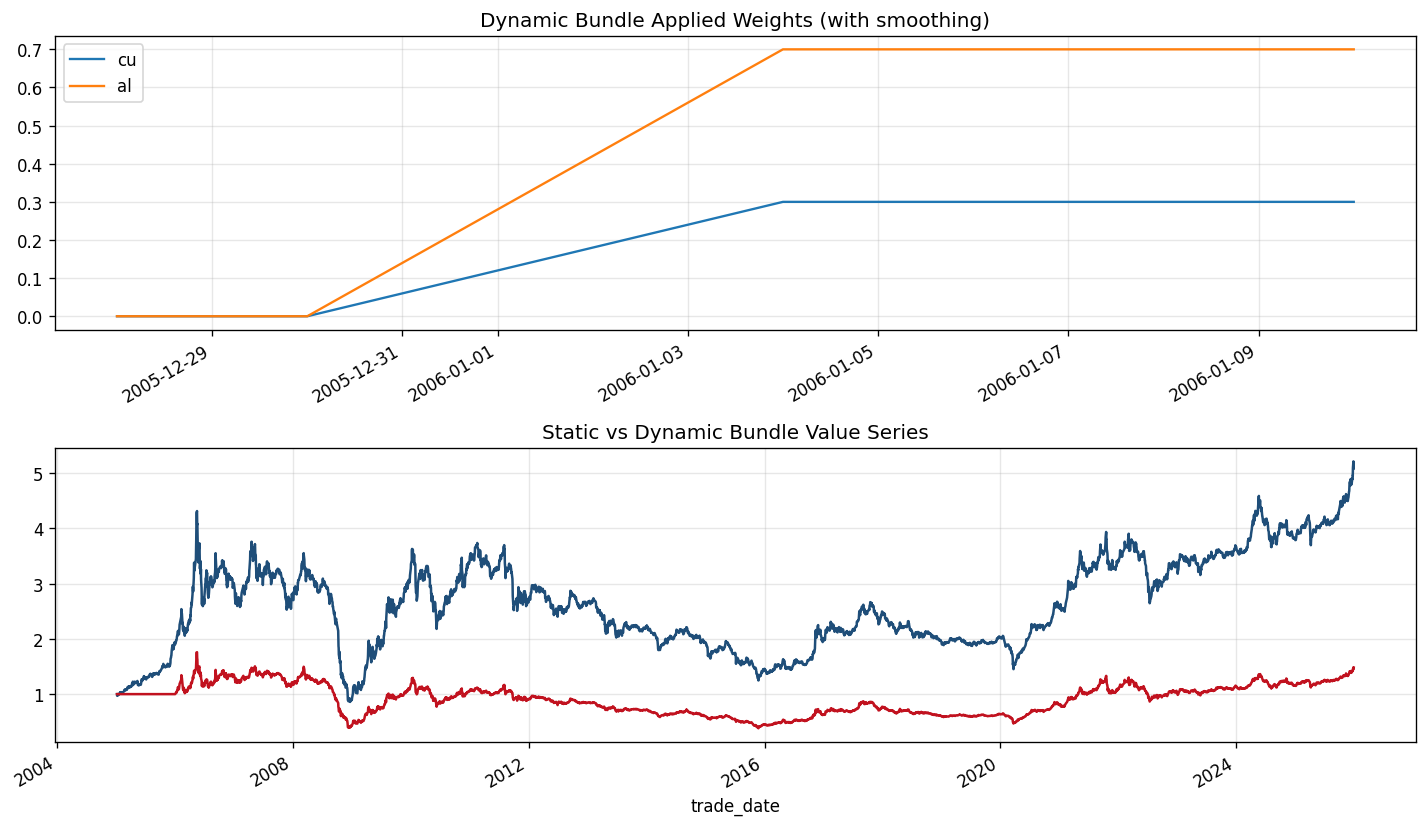

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

dynamic_bundle_result.component_weights.loc['2005-12-28':'2006-01-10'].plot(ax=axes[0], lw=1.4)
axes[0].set_title('Dynamic Bundle Applied Weights (with smoothing)')
axes[0].grid(alpha=0.3)

metal_bundle_result.value_series.rename('Static Bundle').plot(ax=axes[1], lw=1.5, color='#1f4e79')
dynamic_bundle_result.value_series.rename('Dynamic Bundle').plot(ax=axes[1], lw=1.5, color='#c1121f')
axes[1].set_title('Static vs Dynamic Bundle Value Series')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7.5. 看 bundle sync schema 在结果里怎么体现

下面这个例子不追求复杂业务逻辑，只是演示：
- 如何在 `BundleRule` 里声明 `sync_mode / sync_frequency / sync_components`
- 这些信息会怎样写进 `roll_schedule`

这一步的意义是：bundle-level 的同步展期意图，已经有正式的 schema 和结果注记了。


In [21]:
sync_bundle_profile = RollStrategyProfile(
    name='metal_sync_bundle_demo',
    asset_key='CU_AL_SYNC_BUNDLE',
    asset_mode='bundle',
    currency='CNY',
    components=[
        RollComponentProfile(component_key='cu', symbol='CU'),
        RollComponentProfile(component_key='al', symbol='AL'),
    ],
    bundle_rule=BundleRule(
        weight_mode='external',
        rebalance_frequency='monthly',
        smoothing_window=2,
        sync_mode='rebalance',
        sync_frequency='monthly',
        sync_components=['cu', 'al'],
    ),
)

sync_bundle = BundleRollStrategy(sync_bundle_profile)
sync_bundle_result = sync_bundle.run(
    market_data={
        'component_results': {
            'cu': cu_result,
            'al': al_result,
        },
        'component_target_weights': dynamic_target_weights,
    }
)

sync_cols = [
    'trade_date',
    'component_key',
    'contract_id',
    'bundle_sync_mode',
    'bundle_sync_trigger',
    'bundle_sync_scope',
    'bundle_sync_components',
]
display(sync_bundle_result.roll_schedule[sync_cols].head(12))
display(sync_bundle_result.roll_schedule.loc[sync_bundle_result.roll_schedule['bundle_sync_trigger'], sync_cols].head(12))


,trade_date,component_key,contract_id,bundle_sync_mode,bundle_sync_trigger,bundle_sync_scope,bundle_sync_components
0,2005-01-04,cu,CU0503.SHF,rebalance,True,partial,"cu,al"
1,2005-01-05,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
2,2005-01-06,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
3,2005-01-07,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
4,2005-01-10,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
5,2005-01-11,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
6,2005-01-12,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
7,2005-01-13,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
8,2005-01-14,cu,CU0503.SHF,rebalance,False,partial,"cu,al"
9,2005-01-17,cu,CU0503.SHF,rebalance,False,partial,"cu,al"


,trade_date,component_key,contract_id,bundle_sync_mode,bundle_sync_trigger,bundle_sync_scope,bundle_sync_components
0,2005-01-04,cu,CU0503.SHF,rebalance,True,partial,"cu,al"
22,2005-02-01,cu,CU0504.SHF,rebalance,True,partial,"cu,al"
35,2005-03-01,cu,CU0504.SHF,rebalance,True,partial,"cu,al"
36,2005-03-01,cu,CU0505.SHF,rebalance,True,partial,"cu,al"
62,2005-04-01,cu,CU0506.SHF,rebalance,True,partial,"cu,al"
85,2005-05-09,cu,CU0507.SHF,rebalance,True,partial,"cu,al"
102,2005-06-01,cu,CU0507.SHF,rebalance,True,partial,"cu,al"
103,2005-06-01,cu,CU0508.SHF,rebalance,True,partial,"cu,al"
126,2005-07-01,cu,CU0508.SHF,rebalance,True,partial,"cu,al"
149,2005-08-01,cu,CU0509.SHF,rebalance,True,partial,"cu,al"


In [19]:
black_profile = build_gmat3_black_bundle_profile()
black_profile.bundle_rule


BundleRule(weight_mode='external', static_weights=None, weight_min=0.02, weight_max=0.5, rebalance_frequency='annual', smoothing_window=10, sync_mode='rebalance', sync_frequency='annual', sync_components=['rb', 'hc', 'i', 'j', 'jm'], metadata={'history_days': 125})

## 7.6. 用 `run_gmat3_black_bundle(...)` 快速跑一个真实 BLACK 示例

这一步不再使用 `market_data`，而是直接复用 `GMAT3DataAccess`。原因很简单：
当前 `run_gmat3_black_bundle(...)` helper 会按 GMAT3 的旧 `BLACK` 口径，从原始日线里读取 `open_interest * settle_price` 来计算动态权重。

所以这小节的目的不是统一数据源，而是让你快速学会这条最短用法。


In [2]:
gmat3_access = GMAT3DataAccess()
black_component_results = {}
for symbol in ['RB', 'HC', 'I', 'J', 'JM']:
    strategy = GMAT3SingleAssetRollStrategy(gmat3_access, symbol)
    black_component_results[symbol.lower()] = strategy.run_from_access(
        start='2014-04-01',
        end='2016-12-31',
    )

black_market_data = build_gmat3_black_bundle_market_data(
    gmat3_access,
    black_component_results,
)
sorted(black_market_data.keys())


['bundle_sync_dates', 'component_results', 'component_target_weights']

In [3]:
black_result = run_gmat3_black_bundle(
    gmat3_access,
    black_component_results,
    start='2014-04-01',
    end='2016-12-31',
)

display(black_result.component_weights.head())
display(black_result.component_weights.loc['2015-04-01':'2015-04-20'])


,rb,hc,i,j,jm
trade_date,,,,,
2014-04-01,0.200000,0.200000,0.200000,0.200000,0.200000
2014-04-02,0.200000,0.200000,0.200000,0.200000,0.200000
2014-04-03,0.200423,0.200185,0.198536,0.200795,0.200062
2014-04-04,0.199328,0.198740,0.198204,0.201167,0.202560
2014-04-08,0.198112,0.197499,0.198061,0.201248,0.205081


,rb,hc,i,j,jm
trade_date,,,,,
2015-04-01,0.187785,0.211181,0.143705,0.217442,0.239888
2015-04-02,0.185916,0.210657,0.141597,0.219459,0.242371
2015-04-03,0.216660,0.187937,0.159208,0.199685,0.236509
2015-04-07,0.248142,0.167055,0.180309,0.177498,0.226996
2015-04-08,0.279624,0.146173,0.201409,0.155311,0.217483
2015-04-09,0.311107,0.125291,0.222509,0.133124,0.207969
2015-04-10,0.342589,0.104410,0.243610,0.110936,0.198456
2015-04-13,0.374071,0.083528,0.264710,0.088749,0.188942
2015-04-14,0.405553,0.062646,0.285810,0.066562,0.179429


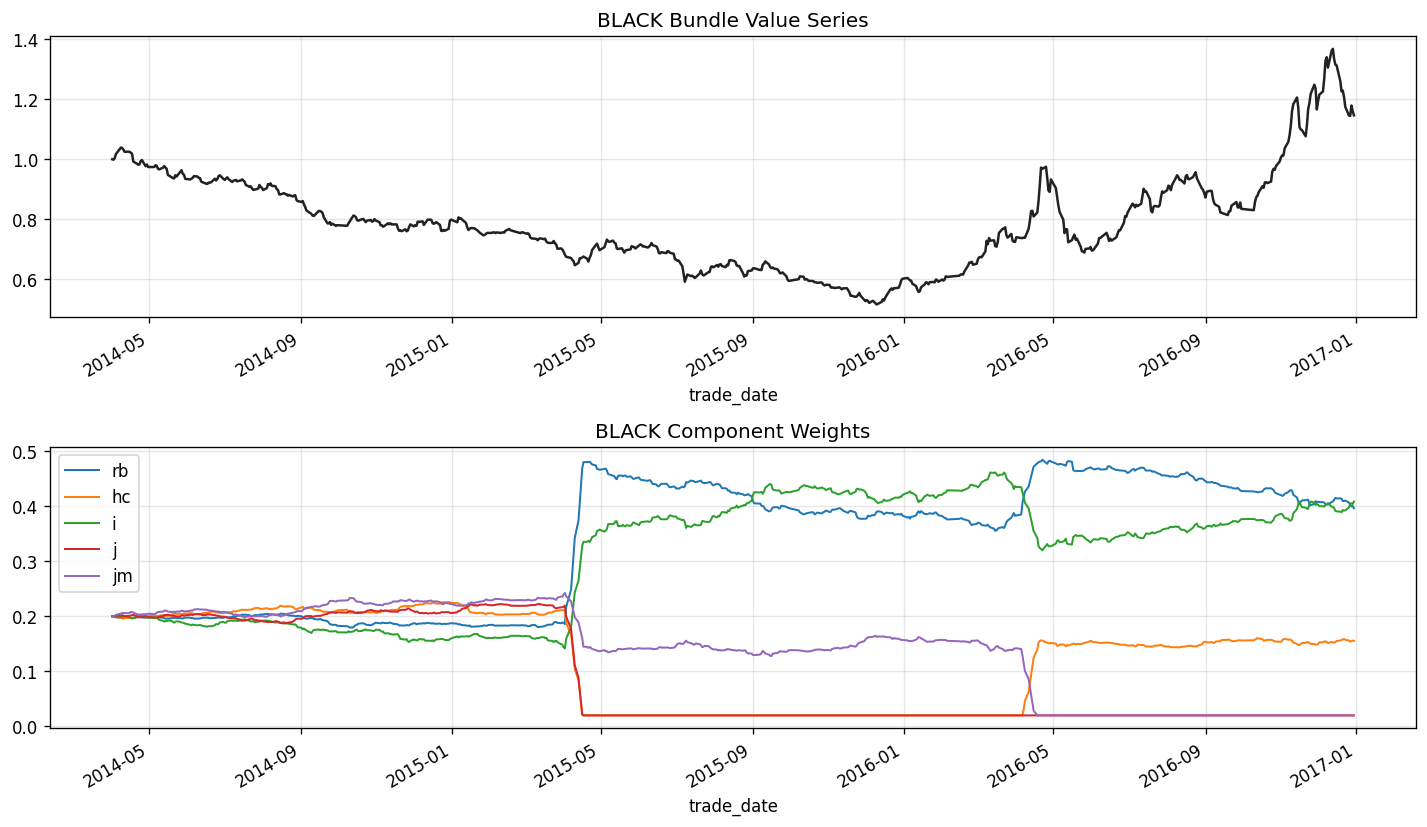

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
black_result.value_series.plot(ax=axes[0], lw=1.5, color='#222222')
axes[0].set_title('BLACK Bundle Value Series')
axes[0].grid(alpha=0.3)

black_result.component_weights.plot(ax=axes[1], lw=1.2)
axes[1].set_title('BLACK Component Weights')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. 怎么理解当前 bundle 的 look-through

当前第一版 bundle 的穿透输出，会把每个 component 的底层持仓拼起来，并额外带上：
- `component_key`
- `bundle_weight`

这已经足够支持你做：
- 某日 bundle 穿透到哪些底层合约
- 每条 component 在 bundle 层的配置比例是多少

In [22]:
sample_date = metal_bundle_result.value_series.index[20]
metal_bundle_result.lookthrough_view(sample_date)

,trade_date,contract_id,exposure_weight,leg,component_key,bundle_weight
22,2005-02-01,CU0504.SHF,1.0,active,cu,0.6
5623,2005-02-01,AL0503.SHF,1.0,active,al,0.4


## 8. 小结：你现在已经能做什么

用当前这套 roll 组件，你已经可以：

1. 在 `market_data` 上构造单资产 generic-contract roll asset
2. 自定义 lifecycle / market-state / execution / selector 组合
3. 查看 `contract_plan / roll_schedule / value_series / lookthrough_book`
4. 把多个单资产 result 组合成一个静态或等权 bundle asset
5. 为后续上层 `signals / portfolio` 研究准备资产级 `value_series`

当前还没有做强的部分：
- dynamic bundle weights
- bundle 级同步展期
- `BLACK` 正式迁移

所以下一步如果你要继续研究，最自然的方向通常有两个：
- 继续做更多单资产 roll rule 对比
- 或开始尝试更复杂的 bundle 级同步展期与动态组合逻辑